<a href="https://colab.research.google.com/github/Sedat8kk/cs4412-pattern-discovery-retail/blob/main/notebooks/M2_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
from google.colab import files
uploaded = files.upload()

Saving online_retail_II.csv to online_retail_II.csv


In [4]:
import os
os.listdir(".")

['.config', 'online_retail_II.csv', 'sample_data']

In [5]:
import pandas as pd

df = pd.read_csv("online_retail_II.csv", encoding="ISO-8859-1")

df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


In [6]:
print("Dataset shape:", df.shape)

print("\nColumns:")
print(df.columns)

df.info()

Dataset shape: (1067371, 8)

Columns:
Index(['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'Price', 'Customer ID', 'Country'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1067371 entries, 0 to 1067370
Data columns (total 8 columns):
 #   Column       Non-Null Count    Dtype  
---  ------       --------------    -----  
 0   Invoice      1067371 non-null  object 
 1   StockCode    1067371 non-null  object 
 2   Description  1062989 non-null  object 
 3   Quantity     1067371 non-null  int64  
 4   InvoiceDate  1067371 non-null  object 
 5   Price        1067371 non-null  float64
 6   Customer ID  824364 non-null   float64
 7   Country      1067371 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 65.1+ MB


In [7]:
df.isnull().sum().sort_values(ascending=False)

,0
Customer ID,243007
Description,4382
StockCode,0
Invoice,0
Quantity,0
InvoiceDate,0
Price,0
Country,0


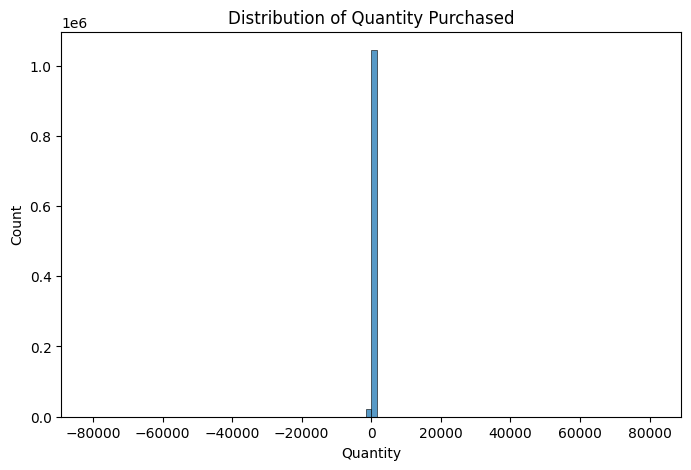

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))
sns.histplot(df["Quantity"], bins=100)
plt.title("Distribution of Quantity Purchased")
plt.show()

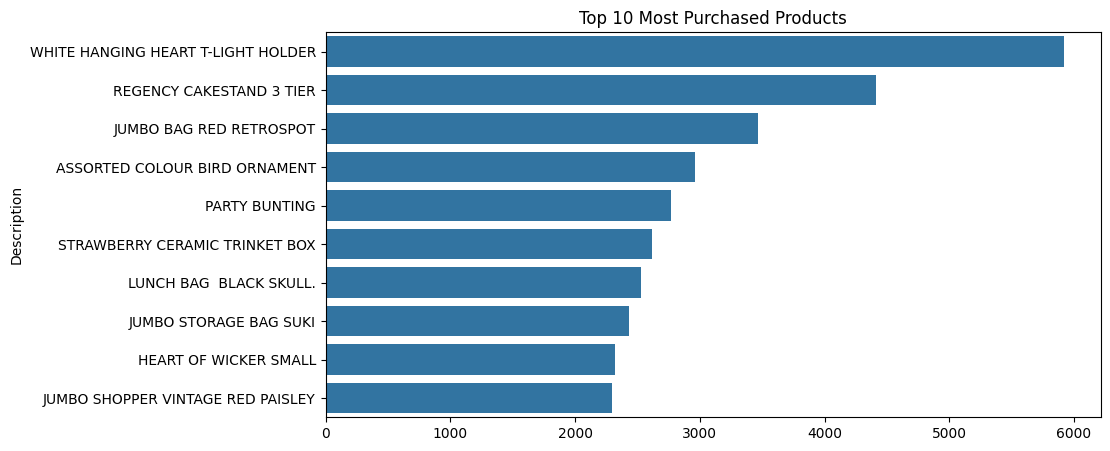

In [9]:
top_products = df["Description"].value_counts().head(10)

plt.figure(figsize=(10,5))
sns.barplot(x=top_products.values, y=top_products.index)
plt.title("Top 10 Most Purchased Products")
plt.show()

In [10]:
df = df[df["Quantity"] > 0]
df = df[df["Price"] > 0]
df = df.dropna(subset=["Customer ID"])

print("Cleaned dataset shape:", df.shape)

Cleaned dataset shape: (805549, 8)


In [11]:
basket = (df
          .groupby(['Invoice', 'Description'])['Quantity']
          .sum()
          .unstack()
          .fillna(0))

basket = basket.applymap(lambda x: 1 if x > 0 else 0)

basket.head()

/tmp/ipykernel_1723/2706470532.py:7: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  basket = basket.applymap(lambda x: 1 if x > 0 else 0)


Description,DOORMAT UNION JACK GUNS AND ROSES,3 STRIPEY MICE FELTCRAFT,4 PURPLE FLOCK DINNER CANDLES,50'S CHRISTMAS GIFT BAG LARGE,ANIMAL STICKERS,BLACK PIRATE TREASURE CHEST,BROWN PIRATE TREASURE CHEST,Bank Charges,CAMPHOR WOOD PORTOBELLO MUSHROOM,CHERRY BLOSSOM DECORATIVE FLASK,...,ZINC STAR T-LIGHT HOLDER,ZINC SWEETHEART SOAP DISH,ZINC SWEETHEART WIRE LETTER RACK,ZINC T-LIGHT HOLDER STAR LARGE,ZINC T-LIGHT HOLDER STARS LARGE,ZINC T-LIGHT HOLDER STARS SMALL,ZINC TOP 2 DOOR WOODEN SHELF,ZINC WILLIE WINKIE CANDLE STICK,ZINC WIRE KITCHEN ORGANISER,ZINC WIRE SWEETHEART LETTER TRAY
Invoice,,,,,,,,,,,,,,,,,,,,,
489434,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
489435,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
489436,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
489437,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
489438,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [13]:
!pip install mlxtend

In [16]:
import pandas as pd
import numpy as np

df2 = df.copy()
df2["Invoice"] = df2["Invoice"].astype(str)

# Remove cancellations & invalid rows
df2 = df2[~df2["Invoice"].str.startswith("C")]
df2 = df2[df2["Quantity"] > 0]
df2 = df2[df2["Price"] > 0]
df2 = df2.dropna(subset=["Description"])

# Reduce size for Colab speed
df2 = df2[df2["Country"] == "United Kingdom"]

TOP_N = 300
top_items = df2["Description"].value_counts().head(TOP_N).index
df2 = df2[df2["Description"].isin(top_items)]

MAX_INVOICES = 20000
keep_invoices = df2["Invoice"].drop_duplicates().head(MAX_INVOICES)
df2 = df2[df2["Invoice"].isin(keep_invoices)]

print("df2 shape:", df2.shape)
print("unique invoices:", df2["Invoice"].nunique())
print("unique products:", df2["Description"].nunique())

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

df2 shape: (175305, 8)
unique invoices: 20000
unique products: 290


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [17]:
basket = (
    df2.groupby(["Invoice", "Description"])["Quantity"]
       .sum()
       .unstack(fill_value=0)
)

basket = basket.gt(0)

print("Basket dtype check:", basket.dtypes.unique())
print("Basket shape:", basket.shape)
basket.head()

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

Basket dtype check: [dtype('bool')]
Basket shape: (20000, 290)


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


Description,12 PENCILS SMALL TUBE SKULL,3 HEARTS HANGING DECORATION RUSTIC,3 STRIPEY MICE FELTCRAFT,4 TRADITIONAL SPINNING TOPS,6 RIBBONS RUSTIC CHARM,60 CAKE CASES VINTAGE CHRISTMAS,60 TEATIME FAIRY CAKE CASES,72 SWEETHEART FAIRY CAKE CASES,AGED GLASS SILVER T-LIGHT HOLDER,ALARM CLOCK BAKELIKE GREEN,...,WOODEN HEART CHRISTMAS SCANDINAVIAN,WOODEN PICTURE FRAME WHITE FINISH,WOODEN ROUNDERS GARDEN SET,WOODEN SCHOOL COLOURING SET,WOODEN STAR CHRISTMAS SCANDINAVIAN,WOODEN UNION JACK BUNTING,WOODLAND CHARLOTTE BAG,WORLD WAR 2 GLIDERS ASSTD DESIGNS,YOU'RE CONFUSING ME METAL SIGN,ZINC METAL HEART DECORATION
Invoice,,,,,,,,,,,,,,,,,,,,,
489434,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
489436,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
489437,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
489438,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
489441,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [18]:
from mlxtend.frequent_patterns import apriori, association_rules

frequent_items = apriori(basket, min_support=0.02, use_colnames=True)
rules = association_rules(frequent_items, metric="lift", min_threshold=1.0)

rules.sort_values(["lift","confidence"], ascending=False).head(10)

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
7,(TOILET METAL SIGN),(BATHROOM METAL SIGN),0.02620,0.03300,0.02025,0.772901,23.421235,1.0,0.019385,4.258050,0.983060,0.519897,0.765151,0.693269
6,(BATHROOM METAL SIGN),(TOILET METAL SIGN),0.03300,0.02620,0.02025,0.613636,23.421235,1.0,0.019385,2.520424,0.989973,0.519897,0.603241,0.693269
45,(WOOD 2 DRAWER CABINET WHITE FINISH),(WOOD S/3 CABINET ANT WHITE FINISH),0.03660,0.04135,0.02185,0.596995,14.437595,1.0,0.020337,2.378752,0.966095,0.389483,0.579611,0.562705
44,(WOOD S/3 CABINET ANT WHITE FINISH),(WOOD 2 DRAWER CABINET WHITE FINISH),0.04135,0.03660,0.02185,0.528416,14.437595,1.0,0.020337,2.042902,0.970882,0.389483,0.510500,0.562705
47,(WOODEN PICTURE FRAME WHITE FINISH),(WOODEN FRAME ANTIQUE WHITE ),0.05225,0.06045,0.03405,0.651675,10.780391,1.0,0.030891,2.697334,0.957256,0.432931,0.629264,0.607475
46,(WOODEN FRAME ANTIQUE WHITE ),(WOODEN PICTURE FRAME WHITE FINISH),0.06045,0.05225,0.03405,0.563275,10.780391,1.0,0.030891,2.170132,0.965610,0.432931,0.539199,0.607475
8,(COOK WITH WINE METAL SIGN ),(GIN + TONIC DIET METAL SIGN),0.04180,0.04720,0.02090,0.500000,10.593220,1.0,0.018927,1.905600,0.945105,0.306902,0.475231,0.471398
9,(GIN + TONIC DIET METAL SIGN),(COOK WITH WINE METAL SIGN ),0.04720,0.04180,0.02090,0.442797,10.593220,1.0,0.018927,1.719659,0.950462,0.306902,0.418489,0.471398
39,(STRAWBERRY CERAMIC TRINKET BOX),(SWEETHEART CERAMIC TRINKET BOX),0.07155,0.04455,0.03305,0.461915,10.368457,1.0,0.029862,1.775648,0.973185,0.397953,0.436825,0.601889
38,(SWEETHEART CERAMIC TRINKET BOX),(STRAWBERRY CERAMIC TRINKET BOX),0.04455,0.07155,0.03305,0.741863,10.368457,1.0,0.029862,3.596735,0.945684,0.397953,0.721970,0.601889


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [19]:
import warnings
warnings.filterwarnings("ignore")

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [22]:
frequent_items = apriori(basket, min_support=0.01, use_colnames=True)

In [23]:
print("Frequent itemsets found:", len(frequent_items))
frequent_items.sort_values("support", ascending=False).head(10)

Frequent itemsets found: 560


,support,itemsets
260,0.18120,(WHITE HANGING HEART T-LIGHT HOLDER)
200,0.10305,(REGENCY CAKESTAND 3 TIER)
16,0.08190,(ASSORTED COLOUR BIRD ORNAMENT)
238,0.07155,(STRAWBERRY CERAMIC TRINKET BOX)
92,0.06970,(HOME BUILDING BLOCK WORD)
109,0.06830,(JUMBO BAG RED RETROSPOT)
204,0.06400,(REX CASH+CARRY JUMBO SHOPPER)
6,0.06185,(60 TEATIME FAIRY CAKE CASES)
90,0.06050,(HEART OF WICKER LARGE)
270,0.06045,(WOODEN FRAME ANTIQUE WHITE )


In [24]:
from mlxtend.frequent_patterns import association_rules

rules = association_rules(frequent_items, metric="lift", min_threshold=1.0)

print("Rules found:", len(rules))
rules.head()

Rules found: 668


,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
0,(3 STRIPEY MICE FELTCRAFT),(FELTCRAFT 6 FLOWER FRIENDS),0.02075,0.04400,0.01030,0.496386,11.281490,1.0,0.009387,1.898278,0.930671,0.189164,0.473207,0.365238
1,(FELTCRAFT 6 FLOWER FRIENDS),(3 STRIPEY MICE FELTCRAFT),0.04400,0.02075,0.01030,0.234091,11.281490,1.0,0.009387,1.278546,0.953305,0.189164,0.217862,0.365238
2,(60 TEATIME FAIRY CAKE CASES),(72 SWEETHEART FAIRY CAKE CASES),0.06185,0.04020,0.01990,0.321746,8.003636,1.0,0.017414,1.415104,0.932747,0.242240,0.293338,0.408386
3,(72 SWEETHEART FAIRY CAKE CASES),(60 TEATIME FAIRY CAKE CASES),0.04020,0.06185,0.01990,0.495025,8.003636,1.0,0.017414,1.857814,0.911707,0.242240,0.461733,0.408386
4,(60 TEATIME FAIRY CAKE CASES),(PACK OF 60 DINOSAUR CAKE CASES),0.06185,0.03505,0.01955,0.316087,9.018183,1.0,0.017382,1.410926,0.947730,0.252747,0.291245,0.436931


In [25]:
top_rules = rules.sort_values(["lift", "confidence"], ascending=False).head(15).copy()

# Make antecedents/consequents readable
top_rules["antecedents"] = top_rules["antecedents"].apply(lambda x: ", ".join(list(x)))
top_rules["consequents"] = top_rules["consequents"].apply(lambda x: ", ".join(list(x)))

top_rules[["antecedents","consequents","support","confidence","lift"]]

,antecedents,consequents,support,confidence,lift
660,"WOOD S/3 CABINET ANT WHITE FINISH, WOODEN PICT...","WOOD 2 DRAWER CABINET WHITE FINISH, WOODEN FRA...",0.01080,0.668731,39.337097
661,"WOOD 2 DRAWER CABINET WHITE FINISH, WOODEN FRA...","WOOD S/3 CABINET ANT WHITE FINISH, WOODEN PICT...",0.01080,0.635294,39.337097
551,GREEN REGENCY TEACUP AND SAUCER,"ROSES REGENCY TEACUP AND SAUCER , PINK REGENCY...",0.01265,0.550000,39.145907
546,"ROSES REGENCY TEACUP AND SAUCER , PINK REGENCY...",GREEN REGENCY TEACUP AND SAUCER,0.01265,0.900356,39.145907
550,PINK REGENCY TEACUP AND SAUCER,"ROSES REGENCY TEACUP AND SAUCER , GREEN REGENC...",0.01265,0.731214,38.586484
547,"ROSES REGENCY TEACUP AND SAUCER , GREEN REGENC...",PINK REGENCY TEACUP AND SAUCER,0.01265,0.667546,38.586484
128,PINK REGENCY TEACUP AND SAUCER,GREEN REGENCY TEACUP AND SAUCER,0.01445,0.835260,36.315657
129,GREEN REGENCY TEACUP AND SAUCER,PINK REGENCY TEACUP AND SAUCER,0.01445,0.628261,36.315657
662,"WOOD 2 DRAWER CABINET WHITE FINISH, WOODEN PIC...","WOOD S/3 CABINET ANT WHITE FINISH, WOODEN FRAM...",0.01080,0.656535,36.073349
659,"WOOD S/3 CABINET ANT WHITE FINISH, WOODEN FRAM...","WOOD 2 DRAWER CABINET WHITE FINISH, WOODEN PIC...",0.01080,0.593407,36.073349


In [26]:
top_rules.to_csv("top_rules.csv", index=False)
print("Saved: top_rules.csv")

Saved: top_rules.csv


In [27]:
top_rules = rules.sort_values(["lift","confidence"], ascending=False).head(20)

top_rules.to_csv("top_rules.csv", index=False)

print("File saved: top_rules.csv")

File saved: top_rules.csv


# CS 4412 – Data Mining
## Milestone 2: Data Exploration and Initial Mining

Dataset: Online Retail II

This notebook performs:
- Data loading and overview
- Exploratory Data Analysis (EDA)
- Data preprocessing
- Association rule mining to discover product co-purchase patterns.